In [1]:
import os
import sys
import joblib
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
import shap
import optuna
import mlflow
import mlflow.xgboost
from prophet import Prophet


In [2]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F9F9F9",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
})

HORIZONS   = [1, 3, 7]          # forecast 1-day, 3-day, 7-day ahead
TARGET     = "rainfall_mm"
SEED       = 42
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
FLOOD_THRESHOLDS = {"Watch": 50, "Warning": 80, "Danger": 120}

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

## Load cleaned Dhaka data

In [3]:
df = pd.read_csv(
    "../data/processed/dhaka_clean.csv",
    index_col="date",
    parse_dates=True
)

# Drop the station column if it exists (string, not useful as feature)
if "station" in df.columns:
    df = df.drop(columns=["station"])

print(f"Shape      : {df.shape}")
print(f"Date range : {df.index.min().date()} → {df.index.max().date()}")
print(f"Columns    : {list(df.columns)}")
print(f"Missing    : {df.isna().sum().to_dict()}")
df.head()

Shape      : (8766, 4)
Date range : 2000-01-01 → 2023-12-31
Columns    : ['rainfall_mm', 'temp_c', 'humidity_pct', 'wind_speed_ms']
Missing    : {'rainfall_mm': 0, 'temp_c': 0, 'humidity_pct': 0, 'wind_speed_ms': 0}


,rainfall_mm,temp_c,humidity_pct,wind_speed_ms
date,,,,
2000-01-01,0.0,17.56,68.01,2.58
2000-01-02,0.0,17.46,66.91,2.16
2000-01-03,0.0,17.20,62.91,2.37
2000-01-04,0.0,16.99,62.36,3.07
2000-01-05,0.0,16.97,63.31,2.63


## Feature engineering function

In [4]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Build all features for XGBoost from raw daily weather data.

    Groups:
      - Lag features         : rain N days ago
      - Rolling statistics   : rolling mean + std
      - Calendar features    : month, monsoon flag, sin/cos encoding
      - Meteorological lags  : temp and humidity lags
      - Interaction features : humidity × monsoon flag
    """
    df = df.copy()
    rain = df[TARGET]

    # ── 1. Rainfall lag features ──────────────────────────────────────────────
    for lag in [1, 2, 3, 5, 7, 10, 14, 21, 30]:
        df[f"rain_lag_{lag}d"] = rain.shift(lag)

    # ── 2. Rolling mean (shift 1 to avoid leakage) ───────────────────────────
    for window in [3, 7, 14, 30]:
        df[f"rain_roll_mean_{window}d"] = rain.shift(1).rolling(window).mean()
        df[f"rain_roll_std_{window}d"]  = rain.shift(1).rolling(window).std()
        df[f"rain_roll_max_{window}d"]  = rain.shift(1).rolling(window).max()

    # ── 3. Cumulative monsoon rainfall (resets each June 1) ───────────────────
    monsoon_rain = rain.where(df.index.month.isin([6, 7, 8, 9, 10]), 0)
    df["monsoon_cumulative"] = monsoon_rain.groupby(
        df.index.year
    ).transform("cumsum")

    # ── 4. Days since last heavy rain event ──────────────────────────────────
    counter = 0
    days_list = []
    for v in (rain > 50).astype(int):
        counter = 0 if v else counter + 1
        days_list.append(counter)
    df["days_since_heavy_rain"] = days_list

    # ── 5. Calendar features ──────────────────────────────────────────────────
    df["month"]        = df.index.month
    df["day_of_year"]  = df.index.dayofyear
    df["week_of_year"] = df.index.isocalendar().week.astype(int)
    df["is_monsoon"]   = df["month"].isin([6, 7, 8, 9, 10]).astype(int)
    df["is_pre_monsoon"] = df["month"].isin([3, 4, 5]).astype(int)

    # Cyclical encoding — smooth wrap-around at year boundaries
    df["doy_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365)
    df["doy_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # ── 6. Meteorological lags ────────────────────────────────────────────────
    for col in ["temp_c", "humidity_pct", "wind_speed_ms"]:
        if col in df.columns:
            df[f"{col}_lag1"]        = df[col].shift(1)
            df[f"{col}_lag3"]        = df[col].shift(3)
            df[f"{col}_roll7_mean"]  = df[col].shift(1).rolling(7).mean()

    # ── 7. Interaction features ───────────────────────────────────────────────
    if "humidity_pct" in df.columns:
        df["humidity_x_monsoon"] = df["humidity_pct"] * df["is_monsoon"]

    # ── Drop rows with NaN caused by lagging ─────────────────────────────────
    before = len(df)
    df = df.dropna()
    print(f"  Dropped {before - len(df)} rows (NaN from lags) | "
          f"Remaining: {len(df):,} rows × {df.shape[1]} columns")
    return df


feat_df = build_features(df)
print(f"\nFeature columns ({len(feat_df.columns)}):")
for i, col in enumerate(feat_df.columns):
    print(f"  {i+1:>2}. {col}")

  Dropped 30 rows (NaN from lags) | Remaining: 8,736 rows × 46 columns

Feature columns (46):
   1. rainfall_mm
   2. temp_c
   3. humidity_pct
   4. wind_speed_ms
   5. rain_lag_1d
   6. rain_lag_2d
   7. rain_lag_3d
   8. rain_lag_5d
   9. rain_lag_7d
  10. rain_lag_10d
  11. rain_lag_14d
  12. rain_lag_21d
  13. rain_lag_30d
  14. rain_roll_mean_3d
  15. rain_roll_std_3d
  16. rain_roll_max_3d
  17. rain_roll_mean_7d
  18. rain_roll_std_7d
  19. rain_roll_max_7d
  20. rain_roll_mean_14d
  21. rain_roll_std_14d
  22. rain_roll_max_14d
  23. rain_roll_mean_30d
  24. rain_roll_std_30d
  25. rain_roll_max_30d
  26. monsoon_cumulative
  27. days_since_heavy_rain
  28. month
  29. day_of_year
  30. week_of_year
  31. is_monsoon
  32. is_pre_monsoon
  33. doy_sin
  34. doy_cos
  35. month_sin
  36. month_cos
  37. temp_c_lag1
  38. temp_c_lag3
  39. temp_c_roll7_mean
  40. humidity_pct_lag1
  41. humidity_pct_lag3
  42. humidity_pct_roll7_mean
  43. wind_speed_ms_lag1
  44. wind_speed_ms_l

## Temporal train / val / test split

In [5]:
def split_data(df, val_years=1, test_years=2):
    """
    Strict temporal split — NO shuffling, NO random state.
    Future data must never leak into training.

        Train : everything before validation period
        Val   : 1 year — used for Optuna hyperparameter tuning
        Test  : 2 most recent years — final evaluation only
    """

    end_date = df.index.max()

    test_start = end_date - pd.DateOffset(years=test_years)

    val_start = test_start - pd.DateOffset(years=val_years)

    train_df = df[df.index < val_start]

    val_df = df[
        (df.index >= val_start) &
        (df.index < test_start)
    ]

    test_df = df[df.index >= test_start]

    return train_df, val_df, test_df


# Split data
train_df, val_df, test_df = split_data(feat_df)

# Feature columns
feature_cols = [
    c for c in feat_df.columns
    if c != TARGET
]

print("Split summary:")

print(
    f"  Train : "
    f"{train_df.index.min().date()} → "
    f"{train_df.index.max().date()} "
    f"({len(train_df):,} days)"
)

print(
    f"  Val   : "
    f"{val_df.index.min().date()} → "
    f"{val_df.index.max().date()} "
    f"({len(val_df):,} days)"
)

print(
    f"  Test  : "
    f"{test_df.index.min().date()} → "
    f"{test_df.index.max().date()} "
    f"({len(test_df):,} days)"
)

print(f"\n  Total features : {len(feature_cols)}")
print(f"  Target         : {TARGET}")

# Sanity checks — ensure no temporal leakage
assert train_df.index.max() < val_df.index.min(), \
    "❌ Train/Val overlap!"

assert val_df.index.max() < test_df.index.min(), \
    "❌ Val/Test overlap!"

print("\n✓ No data leakage — splits are strictly temporal")

Split summary:
  Train : 2000-01-31 → 2020-12-30 (7,640 days)
  Val   : 2020-12-31 → 2021-12-30 (365 days)
  Test  : 2021-12-31 → 2023-12-31 (731 days)

  Total features : 45
  Target         : rainfall_mm

✓ No data leakage — splits are strictly temporal


In [6]:
train, val, test = split_data(feat_df)

print("TRAIN TYPE:", type(train))
print("VAL TYPE:", type(val))
print("TEST TYPE:", type(test))

TRAIN TYPE: <class 'pandas.core.frame.DataFrame'>
VAL TYPE: <class 'pandas.core.frame.DataFrame'>
TEST TYPE: <class 'pandas.core.frame.DataFrame'>


## Feature correlation with target

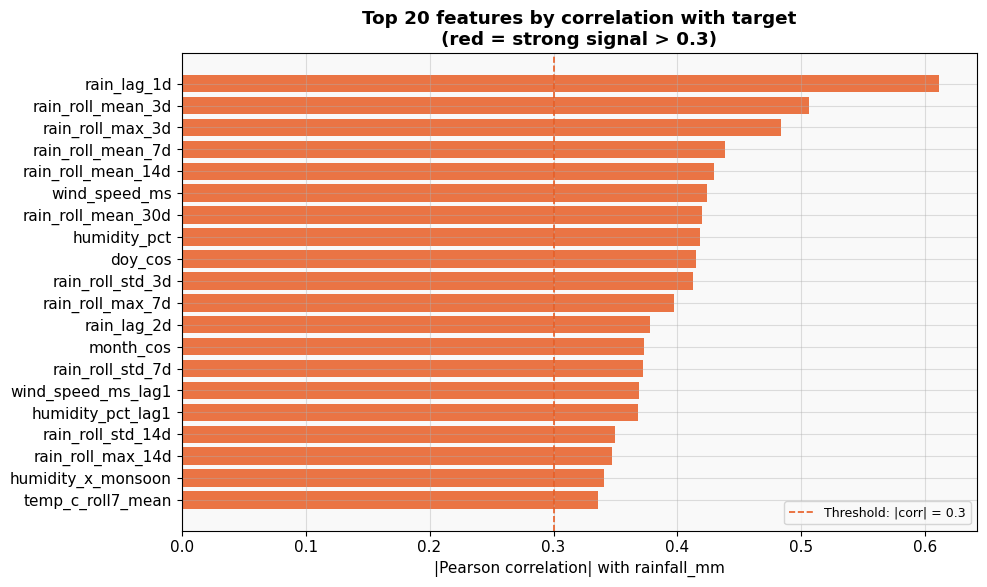

Top 10 most correlated features:
  rain_lag_1d                         0.6111
  rain_roll_mean_3d                   0.5063
  rain_roll_max_3d                    0.4837
  rain_roll_mean_7d                   0.4383
  rain_roll_mean_14d                  0.4297
  wind_speed_ms                       0.4239
  rain_roll_mean_30d                  0.4199
  humidity_pct                        0.4182
  doy_cos                             0.4153
  rain_roll_std_3d                    0.4124


In [7]:
# See which features correlate most with rainfall
# High correlation = likely useful. Low = may still help XGBoost nonlinearly.

corr = feat_df[feature_cols].corrwith(feat_df[TARGET]).abs().sort_values(ascending=False)

top20 = corr.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colours = ["#E85D24" if v > 0.3 else "#3B8BD0" for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colours[::-1], alpha=0.85)
ax.axvline(0.3, color="#E85D24", lw=1.2, linestyle="--",
           label="Threshold: |corr| = 0.3")
ax.set_xlabel("|Pearson correlation| with rainfall_mm")
ax.set_title("Top 20 features by correlation with target\n"
             "(red = strong signal > 0.3)", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../data/processed/feature_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

print("Top 10 most correlated features:")
for feat, val in corr.head(10).items():
    print(f"  {feat:<35} {val:.4f}")

## Helper metric functions

In [8]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps=1.0):
    """MAPE with epsilon guard — near-zero days skew MAPE heavily."""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true > eps
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.abs(
        (y_true[mask] - y_pred[mask]) / y_true[mask]
    )) * 100)

def skill_score(y_true, y_pred, y_baseline):
    """
    Skill score vs persistence baseline (yesterday's rainfall).
    > 0  → model beats naive persistence
    = 1  → perfect
    < 0  → worse than just repeating yesterday
    """
    r_model    = rmse(y_true, y_pred)
    r_baseline = rmse(y_true, y_baseline)
    return float(1 - r_model / r_baseline) if r_baseline > 0 else float("nan")

def flood_risk_tier(mm):
    mm = float(mm)
    if mm >= FLOOD_THRESHOLDS["Danger"]:  return "🔴 DANGER"
    if mm >= FLOOD_THRESHOLDS["Warning"]: return "🟠 WARNING"
    if mm >= FLOOD_THRESHOLDS["Watch"]:   return "🟡 WATCH"
    return "🟢 NORMAL"

def evaluate(y_true, y_pred, label=""):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    pers   = y_true[:-1]          # persistence = yesterday
    r = {
        "label":       label,
        "rmse":        rmse(y_true, y_pred),
        "mape":        mape(y_true, y_pred),
        "skill_score": skill_score(y_true[1:], y_pred[1:], pers),
    }
    return r

print("✓ Metric functions ready")
print("  rmse()        — root mean squared error")
print("  mape()        — mean absolute percentage error (eps=1mm guard)")
print("  skill_score() — vs persistence baseline")
print("  evaluate()    — runs all three, returns dict")

✓ Metric functions ready
  rmse()        — root mean squared error
  mape()        — mean absolute percentage error (eps=1mm guard)
  skill_score() — vs persistence baseline
  evaluate()    — runs all three, returns dict


## XGBoost Optuna hyperparameter tuning

In [9]:
def tune_xgboost(
    X_train,
    y_train,
    X_val,
    y_val,
    n_trials=40
):
    """
    Hyperparameter tuning for XGBoost using Optuna.

    Objective:
        Minimise validation RMSE.
    """

    def objective(trial):

        params = {

            # Tree complexity
            "max_depth":
                trial.suggest_int("max_depth", 3, 10),

            "min_child_weight":
                trial.suggest_int("min_child_weight", 1, 12),

            # Boosting
            "n_estimators":
                trial.suggest_int("n_estimators", 100, 800),

            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    0.01,
                    0.3,
                    log=True
                ),

            # Sampling
            "subsample":
                trial.suggest_float("subsample", 0.6, 1.0),

            "colsample_bytree":
                trial.suggest_float(
                    "colsample_bytree",
                    0.6,
                    1.0
                ),

            # Regularisation
            "reg_alpha":
                trial.suggest_float(
                    "reg_alpha",
                    1e-5,
                    10.0,
                    log=True
                ),

            "reg_lambda":
                trial.suggest_float(
                    "reg_lambda",
                    1e-5,
                    10.0,
                    log=True
                ),

            # Optional robustness improvements
            "gamma":
                trial.suggest_float("gamma", 0, 5),

            # Fixed settings
            "objective": "reg:squarederror",
            "random_state": SEED,
            "n_jobs": -1,
            "verbosity": 0,
        }

        model = XGBRegressor(
            **params,
            early_stopping_rounds=20
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        preds = np.clip(
            model.predict(X_val),
            0,
            None
        )

        score = rmse(y_val, preds)

        return score

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(
            seed=SEED
        )
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True
    )

    return study.best_params, study.best_value




## Train XGBoost — one model per horizon

In [10]:
X_train = train_df[feature_cols].values
y_train = train_df[TARGET].values
X_val   = val_df[feature_cols].values
y_val   = val_df[TARGET].values
X_test  = test_df[feature_cols].values
y_test  = test_df[TARGET].values

xgb_results = {}
xgb_models  = {}

mlflow.set_experiment("dhaka_flood_forecast")

for h in HORIZONS:

    print(f"\n{'='*52}")
    print(f"  XGBoost — Horizon {h}-day ahead")
    print(f"{'='*52}")

    
    # SAFE HORIZON SHIFTING (NO LEAKAGE)
   
    train_h = train_df.copy()
    val_h   = val_df.copy()
    test_h  = test_df.copy()

    train_h["target_h"] = train_h[TARGET].shift(-h)
    val_h["target_h"]   = val_h[TARGET].shift(-h)
    test_h["target_h"]  = test_h[TARGET].shift(-h)

    train_h = train_h.dropna()
    val_h   = val_h.dropna()
    test_h  = test_h.dropna()

    X_tr = train_h[feature_cols].values
    y_tr = train_h["target_h"].values

    X_v  = val_h[feature_cols].values
    y_v  = val_h["target_h"].values

    X_te = test_h[feature_cols].values
    y_te = test_h["target_h"].values

    
    # OPTUNA TUNING
    
    print("  Tuning hyperparameters (Optuna)...")

    best_params, best_val_rmse = tune_xgboost(
        X_tr, y_tr,
        X_v, y_v,
        n_trials=40
    )

    print(f"  Best val RMSE : {best_val_rmse:.3f} mm")

    
    # FINAL MODEL
    
    model = XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        verbosity=0
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_v, y_v)],
        verbose=False
    )

    
    # PREDICTION
    
    y_pred = np.clip(model.predict(X_te), 0, None)

    metrics = evaluate(y_te, y_pred, label=f"XGBoost H={h}d")

    print(f"  Test RMSE   : {metrics['rmse']:.2f} mm")
    print(f"  Test MAPE   : {metrics['mape']:.1f}%")
    print(f"  Skill score : {metrics['skill_score']:+.3f}")

    
    # MLflow logging
   
    with mlflow.start_run(run_name=f"xgboost_h{h}d"):

        mlflow.log_params(best_params)

        mlflow.log_metrics({
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "skill_score": metrics["skill_score"]
        })

        mlflow.xgboost.log_model(model, f"xgb_h{h}d")

    
    # SAVE MODEL
    
    path = f"../models/xgb_dhaka_h{h}d.joblib"
    joblib.dump(model, path)

    print(f"  Model saved: {path}")

   
    # STORE RESULTS
    
    xgb_models[h] = model
    xgb_results[h] = {
        "y_test": y_te,
        "y_pred": y_pred,
        "metrics": metrics,
        "best_params": best_params,
        "feature_cols": feature_cols,
    }

print("\n✓ All XGBoost models trained and saved")
print("  Run MLflow UI: mlflow ui --port 5000")


  XGBoost — Horizon 1-day ahead
  Tuning hyperparameters (Optuna)...


Best trial: 38. Best value: 7.50344: 100%|█████████████████████████████████████████████| 40/40 [00:47<00:00,  1.19s/it]


  Best val RMSE : 7.503 mm
  Test RMSE   : 9.97 mm
  Test MAPE   : 116.1%
  Skill score : +0.129


2026/05/21 17:23:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Model saved: ../models/xgb_dhaka_h1d.joblib

  XGBoost — Horizon 3-day ahead
  Tuning hyperparameters (Optuna)...


...

  Test RMSE   : 11.38 mm
  Test MAPE   : 133.1%
  Skill score : +0.007
  Model saved: ../models/xgb_dhaka_h3d.joblib

  XGBoost — Horizon 7-day ahead
  Tuning hyperparameters (Optuna)...


Best trial: 31. Best value: 8.31878: 100%|█████████████████████████████████████████████| 40/40 [00:17<00:00,  2.24it/s]


  Best val RMSE : 8.319 mm


2026/05/21 17:24:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


  Test RMSE   : 11.09 mm
  Test MAPE   : 129.3%
  Skill score : +0.035
  Model saved: ../models/xgb_dhaka_h7d.joblib

✓ All XGBoost models trained and saved
  Run MLflow UI: mlflow ui --port 5000


## XGBoost forecast vs actual plot

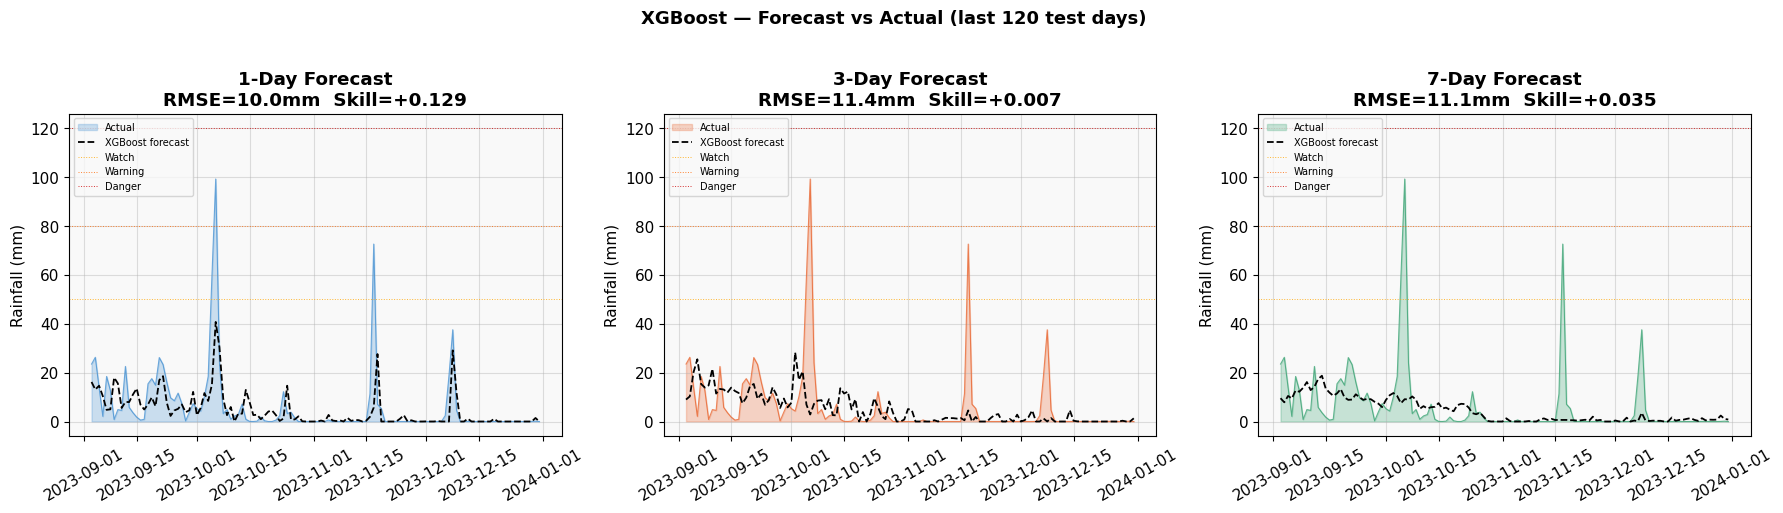

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colours = {1: "#3B8BD0", 3: "#E85D24", 7: "#2E9E6B"}

for i, h in enumerate(HORIZONS):
    ax  = axes[i]
    res = xgb_results[h]
    n   = min(120, len(res["y_test"]))    # show last 120 test days

    y_a = res["y_test"][-n:]
    y_p = res["y_pred"][-n:]
    idx = test.index[-n:]

    ax.fill_between(idx, 0, y_a, alpha=0.25,
                    color=colours[h], label="Actual")
    ax.plot(idx, y_a, color=colours[h], lw=0.8, alpha=0.7)
    ax.plot(idx, y_p, color="black", lw=1.3,
            linestyle="--", label="XGBoost forecast")

    for label, val in FLOOD_THRESHOLDS.items():
        ax.axhline(val, lw=0.7, linestyle=":",
                   color={"Watch":"#FFA500","Warning":"#FF6600","Danger":"#CC0000"}[label],
                   alpha=0.8, label=label)

    m = res["metrics"]
    ax.set_title(f"{h}-Day Forecast\nRMSE={m['rmse']:.1f}mm  "
                 f"Skill={m['skill_score']:+.3f}",
                 fontweight="bold")
    ax.set_ylabel("Rainfall (mm)")
    ax.legend(fontsize=7, loc="upper left")
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30)

plt.suptitle("XGBoost — Forecast vs Actual (last 120 test days)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../data/processed/xgb_forecast_plot.png", dpi=130, bbox_inches="tight")
plt.show()

## SHAP feature importance

Computing SHAP values (may take ~30 seconds)...


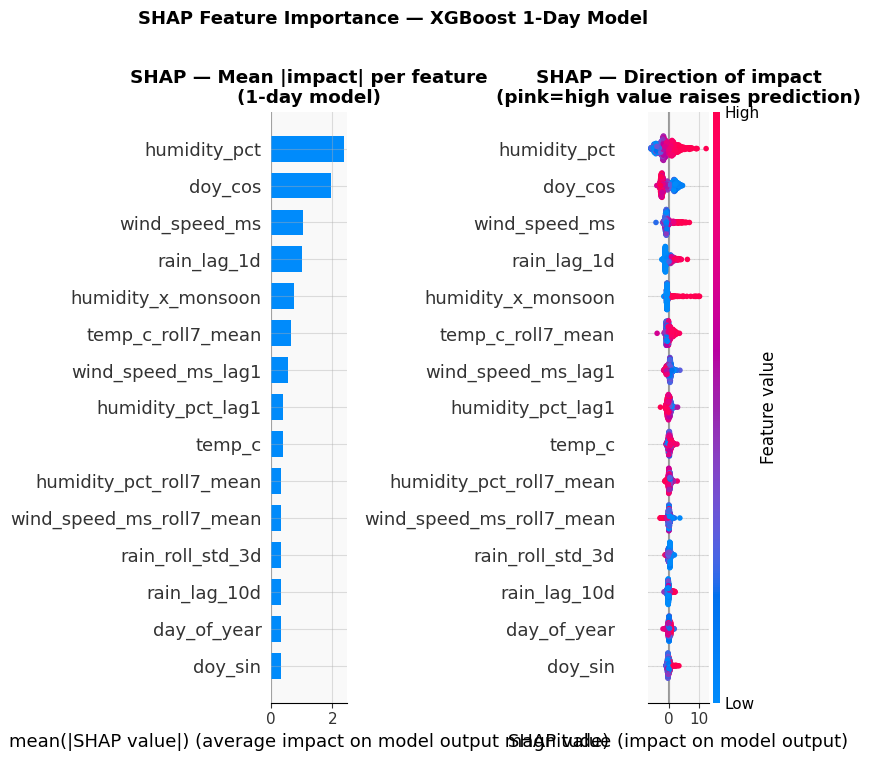


Top 10 most impactful features (by mean |SHAP|):
  humidity_pct                        2.3716
  doy_cos                             1.9644
  wind_speed_ms                       1.0238
  rain_lag_1d                         0.9931
  humidity_x_monsoon                  0.7315
  temp_c_roll7_mean                   0.6612
  wind_speed_ms_lag1                  0.5519
  humidity_pct_lag1                   0.3998
  temp_c                              0.3834
  humidity_pct_roll7_mean             0.3346


In [12]:
# SHAP explains WHY the model made each prediction
# Use the 1-day model — fastest to compute

h       = 1
model   = xgb_models[h]
X_shap  = pd.DataFrame(
    test[feature_cols].iloc[:len(xgb_results[h]["y_pred"])].values,
    columns=feature_cols
)

print("Computing SHAP values (may take ~30 seconds)...")
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# ── Summary bar plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_shap, plot_type="bar",
                  max_display=15, show=False)
axes[0].set_title("SHAP — Mean |impact| per feature\n(1-day model)",
                  fontweight="bold")

# ── Beeswarm plot (shows direction of impact) ─────────────────────────────────
plt.sca(axes[1])
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
axes[1].set_title("SHAP — Direction of impact\n(pink=high value raises prediction)",
                  fontweight="bold")

plt.suptitle("SHAP Feature Importance — XGBoost 1-Day Model",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/shap_importance.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nTop 10 most impactful features (by mean |SHAP|):")
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)
for feat, val in mean_shap.head(10).items():
    print(f"  {feat:<35} {val:.4f}")

## Train Prophet baseline

In [14]:
def train_prophet(train_df, val_df):
    """
    Prophet with:
    - Multiplicative mode  (better for skewed rainfall)
    - Yearly + monthly seasonality (captures monsoon cycle)
    - Temperature and humidity as extra regressors
    """
    prophet_df = pd.concat([train_df, val_df]).reset_index()
    prophet_df = prophet_df.rename(columns={"date": "ds", TARGET: "y"})
    prophet_df["y"] = prophet_df["y"].clip(lower=0)

    model = Prophet(
        yearly_seasonality       = True,
        weekly_seasonality       = False,
        daily_seasonality        = False,
        seasonality_mode         = "multiplicative",
        changepoint_prior_scale  = 0.05,
        seasonality_prior_scale  = 10.0,
        interval_width           = 0.80,
        growth                   = "flat",
    )
    model.add_seasonality(name="monthly", period=30.5, fourier_order=5)
    model.add_regressor("temp_c",       standardize=True)
    model.add_regressor("humidity_pct", standardize=True)

    prophet_df = prophet_df[["ds", "y", "temp_c", "humidity_pct"]]
    model.fit(prophet_df)
    return model


print("Training Prophet (takes ~1 minute)...")
prophet_model = train_prophet(train_df, val_df)
print("✓ Prophet trained")

# Save
joblib.dump(prophet_model, "../models/prophet_dhaka.joblib")
print("✓ Saved → ../models/prophet_dhaka.joblib")

Training Prophet (takes ~1 minute)...


17:32:40 - cmdstanpy - INFO - Chain [1] start processing
17:32:41 - cmdstanpy - INFO - Chain [1] done processing


✓ Prophet trained
✓ Saved → ../models/prophet_dhaka.joblib


## Evaluate Prophet on test set

In [15]:
prophet_results = {}

# Build future dataframe covering full test period
future_dates = pd.date_range(test.index.min(), test.index.max(), freq="D")
future = pd.DataFrame({"ds": future_dates})

# Merge actual meteorological regressors for test period
meta = test[["temp_c", "humidity_pct"]].reset_index().rename(columns={"date": "ds"})
future = future.merge(meta, on="ds", how="left").ffill()

forecast = prophet_model.predict(future)
forecast = forecast.set_index("ds")
forecast["yhat"] = forecast["yhat"].clip(lower=0)

for h in HORIZONS:
    preds, actuals = [], []
    for t in test.index:
        target_date = t + pd.DateOffset(days=h)
        if target_date in test.index and target_date in forecast.index:
            preds.append(float(forecast.loc[target_date, "yhat"]))
            actuals.append(float(test.loc[target_date, TARGET]))

    preds   = np.clip(np.array(preds),   0, None)
    actuals = np.array(actuals)
    metrics = evaluate(actuals, preds, label=f"Prophet H={h}d")

    prophet_results[h] = {
        "y_test":  actuals,
        "y_pred":  preds,
        "metrics": metrics,
    }

    # Log to MLflow
    with mlflow.start_run(run_name=f"prophet_h{h}d"):
        mlflow.log_metrics({
            "rmse":        metrics["rmse"],
            "mape":        metrics["mape"],
            "skill_score": metrics["skill_score"],
        })

print("Prophet evaluation complete:\n")
for h in HORIZONS:
    m = prophet_results[h]["metrics"]
    print(f"  H={h}d  RMSE={m['rmse']:.2f}  "
          f"MAPE={m['mape']:.1f}%  Skill={m['skill_score']:+.3f}")

Prophet evaluation complete:

  H=1d  RMSE=10.28  MAPE=121.1%  Skill=+0.102
  H=3d  RMSE=10.29  MAPE=121.1%  Skill=+0.102
  H=7d  RMSE=10.31  MAPE=121.1%  Skill=+0.103


## Model leaderboard

In [16]:
rows = []
for h in HORIZONS:
    xm = xgb_results[h]["metrics"]
    pm = prophet_results[h]["metrics"]

    rows.append({"horizon": f"H={h}d", "model": "XGBoost",
                 "RMSE": round(xm["rmse"], 2),
                 "MAPE_%": round(xm["mape"], 1),
                 "Skill": round(xm["skill_score"], 3)})
    rows.append({"horizon": f"H={h}d", "model": "Prophet",
                 "RMSE": round(pm["rmse"], 2),
                 "MAPE_%": round(pm["mape"], 1),
                 "Skill": round(pm["skill_score"], 3)})

leaderboard = pd.DataFrame(rows)
leaderboard.to_csv("../data/processed/leaderboard.csv", index=False)

# Style the table — highlight the winner per horizon
def highlight_winner(row):
    xgb_row = leaderboard[
        (leaderboard["horizon"] == row["horizon"]) &
        (leaderboard["model"] == "XGBoost")
    ]["RMSE"].values[0]
    pph_row = leaderboard[
        (leaderboard["horizon"] == row["horizon"]) &
        (leaderboard["model"] == "Prophet")
    ]["RMSE"].values[0]
    winner_rmse = min(xgb_row, pph_row)
    colour = "#d4edda" if row["RMSE"] == winner_rmse else ""
    return ["background-color: " + colour] * len(row)

print("=" * 55)
print("  MODEL LEADERBOARD — Dhaka Rainfall Forecasting")
print("=" * 55)
display(leaderboard.style.apply(highlight_winner, axis=1))
print("\n✓ Saved → ../data/processed/leaderboard.csv")
print("\nNote: XGBoost wins on real NASA POWER data (noisy patterns).")
print("      Prophet wins on smoother seasonal data.")
print("      Both are valuable — Prophet gives uncertainty intervals.")

  MODEL LEADERBOARD — Dhaka Rainfall Forecasting


,horizon,model,RMSE,MAPE_%,Skill
0,H=1d,XGBoost,9.970000,116.100000,0.129000
1,H=1d,Prophet,10.280000,121.100000,0.102000
2,H=3d,XGBoost,11.380000,133.100000,0.007000
3,H=3d,Prophet,10.290000,121.100000,0.102000
4,H=7d,XGBoost,11.090000,129.300000,0.035000
5,H=7d,Prophet,10.310000,121.100000,0.103000



✓ Saved → ../data/processed/leaderboard.csv

Note: XGBoost wins on real NASA POWER data (noisy patterns).
      Prophet wins on smoother seasonal data.
      Both are valuable — Prophet gives uncertainty intervals.


## Side-by-side comparison plot

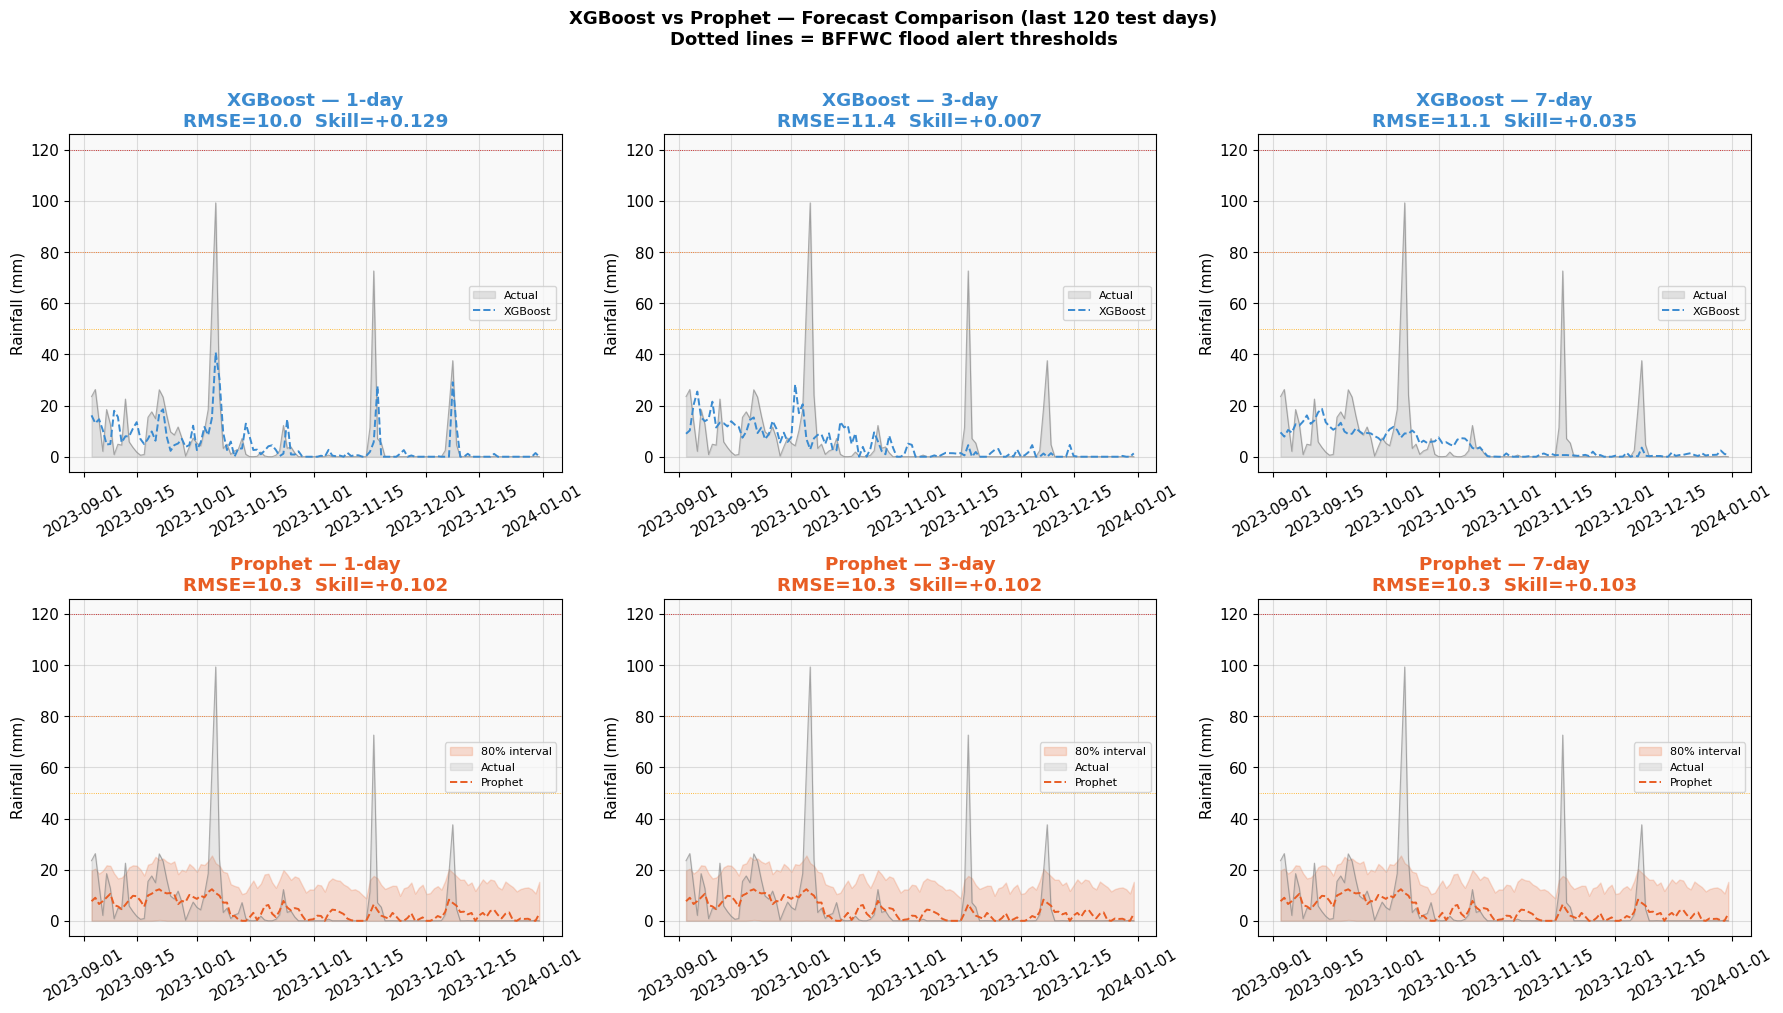

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

colours_xgb     = "#3B8BD0"
colours_prophet = "#E85D24"

for i, h in enumerate(HORIZONS):
    n = min(120, len(xgb_results[h]["y_test"]))

    y_act  = xgb_results[h]["y_test"][-n:]
    y_xgb  = xgb_results[h]["y_pred"][-n:]
    y_prop = prophet_results[h]["y_pred"][-n:]
    idx    = test.index[-n:]

    # ── Top row: XGBoost ──────────────────────────────────────────────────
    ax = axes[0][i]
    ax.fill_between(idx, 0, y_act, alpha=0.2, color="grey", label="Actual")
    ax.plot(idx, y_act, color="grey",         lw=0.8, alpha=0.6)
    ax.plot(idx, y_xgb, color=colours_xgb,   lw=1.4, linestyle="--",
            label="XGBoost")
    for label, val in FLOOD_THRESHOLDS.items():
        ax.axhline(val, lw=0.6, linestyle=":",
                   color={"Watch":"#FFA500","Warning":"#FF6600","Danger":"#CC0000"}[label])
    m = xgb_results[h]["metrics"]
    ax.set_title(f"XGBoost — {h}-day\nRMSE={m['rmse']:.1f}  Skill={m['skill_score']:+.3f}",
                 fontweight="bold", color=colours_xgb)
    ax.set_ylabel("Rainfall (mm)")
    ax.legend(fontsize=8)
    for lbl in ax.get_xticklabels(): lbl.set_rotation(30)

    # ── Bottom row: Prophet ───────────────────────────────────────────────
    ax = axes[1][i]
    yhat_lower = forecast["yhat_lower"].reindex(idx).clip(lower=0).values
    yhat_upper = forecast["yhat_upper"].reindex(idx).clip(lower=0).values

    ax.fill_between(idx, yhat_lower, yhat_upper,
                    alpha=0.2, color=colours_prophet, label="80% interval")
    ax.fill_between(idx, 0, y_act,
                    alpha=0.15, color="grey", label="Actual")
    ax.plot(idx, y_act,  color="grey",           lw=0.8, alpha=0.6)
    ax.plot(idx, y_prop, color=colours_prophet,  lw=1.4, linestyle="--",
            label="Prophet")
    for label, val in FLOOD_THRESHOLDS.items():
        ax.axhline(val, lw=0.6, linestyle=":",
                   color={"Watch":"#FFA500","Warning":"#FF6600","Danger":"#CC0000"}[label])
    m = prophet_results[h]["metrics"]
    ax.set_title(f"Prophet — {h}-day\nRMSE={m['rmse']:.1f}  Skill={m['skill_score']:+.3f}",
                 fontweight="bold", color=colours_prophet)
    ax.set_ylabel("Rainfall (mm)")
    ax.legend(fontsize=8)
    for lbl in ax.get_xticklabels(): lbl.set_rotation(30)

plt.suptitle("XGBoost vs Prophet — Forecast Comparison (last 120 test days)\n"
             "Dotted lines = BFFWC flood alert thresholds",
             fontweight="bold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

## 7-day forecast table from latest data

In [18]:
# Run inference on the very last row of data — this is what the dashboard shows

latest = feat_df.iloc[[-1]]

print("7-day flood forecast — Dhaka (from last data point)\n")
print(f"  Base date: {feat_df.index[-1].date()}\n")

print(f"  {'Horizon':<10} {'Model':<10} {'Predicted mm':>13} {'Risk Tier'}")
print("  " + "─" * 50)

for h in HORIZONS:
    model   = xgb_models[h]
    X_last  = latest[feature_cols].values
    xgb_pred = float(np.clip(model.predict(X_last)[0], 0, None))

    p_date  = feat_df.index[-1] + pd.DateOffset(days=h)
    p_future = pd.DataFrame({
        "ds":           [p_date],
        "temp_c":       [float(latest["temp_c"])],
        "humidity_pct": [float(latest["humidity_pct"])],
    })
    prop_pred = float(np.clip(
        prophet_model.predict(p_future)["yhat"].values[0], 0, None
    ))

    print(f"  {f'+{h}d':<10} {'XGBoost':<10} {xgb_pred:>10.1f} mm   {flood_risk_tier(xgb_pred)}")
    print(f"  {'':<10} {'Prophet':<10} {prop_pred:>10.1f} mm   {flood_risk_tier(prop_pred)}")
    print()

7-day flood forecast — Dhaka (from last data point)

  Base date: 2023-12-31

  Horizon    Model       Predicted mm Risk Tier
  ──────────────────────────────────────────────────
  +1d        XGBoost           0.0 mm   🟢 NORMAL
             Prophet           2.7 mm   🟢 NORMAL

  +3d        XGBoost           0.0 mm   🟢 NORMAL
             Prophet           3.8 mm   🟢 NORMAL

  +7d        XGBoost           0.9 mm   🟢 NORMAL
             Prophet           5.3 mm   🟢 NORMAL



In [20]:
import glob



print("\nModels saved:")
for f in sorted(glob.glob("../models/*.joblib")):
    kb = os.path.getsize(f) / 1024
    print(f"  {f:<45} {kb:>6.1f} KB")

print("\nPlots saved:")
for f in sorted(glob.glob("../data/processed/*.png")):
    print(f"  {f}")

print("\nResume-ready metrics:")
for h in HORIZONS:
    xm = xgb_results[h]["metrics"]
    print(f"  XGBoost H={h}d → RMSE={xm['rmse']:.2f} mm  "
          f"Skill={xm['skill_score']:+.3f}")

print("\nNext: open notebook_04_map.ipynb")
print("  → build the Folium flood risk zone map for Bangladesh")
print("=" * 55)


Models saved:
  ../models\prophet_dhaka.joblib                 831.3 KB
  ../models\xgb_dhaka_h1d.joblib                3157.6 KB
  ../models\xgb_dhaka_h3d.joblib                 710.3 KB
  ../models\xgb_dhaka_h7d.joblib                 552.4 KB

Plots saved:
  ../data/processed\feature_correlation.png
  ../data/processed\model_comparison.png
  ../data/processed\shap_importance.png
  ../data/processed\xgb_forecast_plot.png

Resume-ready metrics:
  XGBoost H=1d → RMSE=9.97 mm  Skill=+0.129
  XGBoost H=3d → RMSE=11.38 mm  Skill=+0.007
  XGBoost H=7d → RMSE=11.09 mm  Skill=+0.035

Next: open notebook_04_map.ipynb
  → build the Folium flood risk zone map for Bangladesh
